# ETE 2 — Iris classification with an MLP: two hidden-layer architectures compared

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import (train_test_split, cross_validate,
                                     RepeatedStratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Understand the raw data

Load Iris straight from `sklearn` as a DataFrame. The shape, the column types, the summary statistics and the class balance decide most of the preprocessing that follows.

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

feature_names = list(iris.feature_names)
print("Shape:", df.shape)
print("Features:", feature_names)
print("Classes:", list(map(str, iris.target_names)))
df.head()

Shape: (150, 6)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print(df.dtypes, "\n")
print("Class counts:\n", df["species"].value_counts(), "\n")
df[feature_names].describe().T

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species                  str
dtype: object 

Class counts:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64 



,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


150 rows, 4 numeric features, 3 species with exactly 50 rows each. The classes are perfectly balanced, so plain accuracy is a fair headline metric and no class weighting is needed. The feature ranges are not comparable though: sepal length spans 4.3–7.9 cm while petal width spans 0.1–2.5 cm, and the standard deviations differ by about 4x.

### Distributions per class

Histograms split by species show whether any single feature already separates the classes, which sets the expectation for how much capacity the network actually needs.

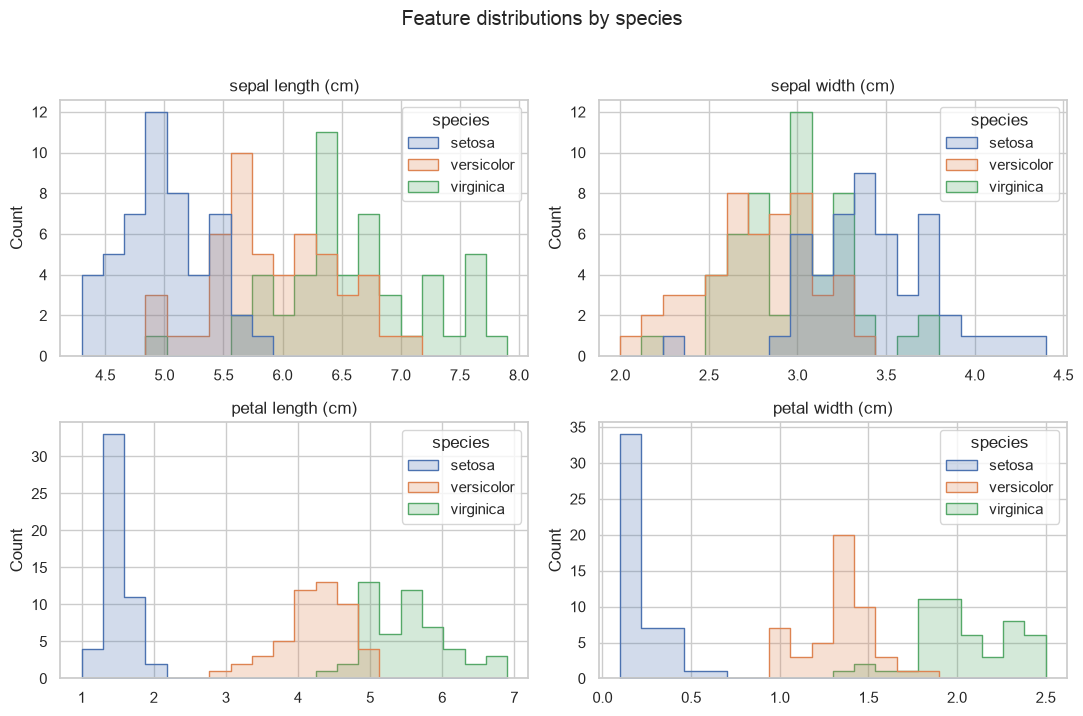

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), feature_names):
    sns.histplot(data=df, x=col, hue="species", element="step", bins=20, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Feature distributions by species", y=1.02)
plt.tight_layout()
plt.show()

Petal length and petal width separate setosa completely and leave only a small overlap between versicolor and virginica. The sepal features overlap much more, sepal width worst of all. A problem where one class is linearly separable and the other two are almost separable does not need a deep network.

### Outliers and spread

A boxplot per feature shows the raw scale difference and any points far from the bulk of the data, and the skew tells us whether the distributions are symmetric. Together those two answers pick the scaler.

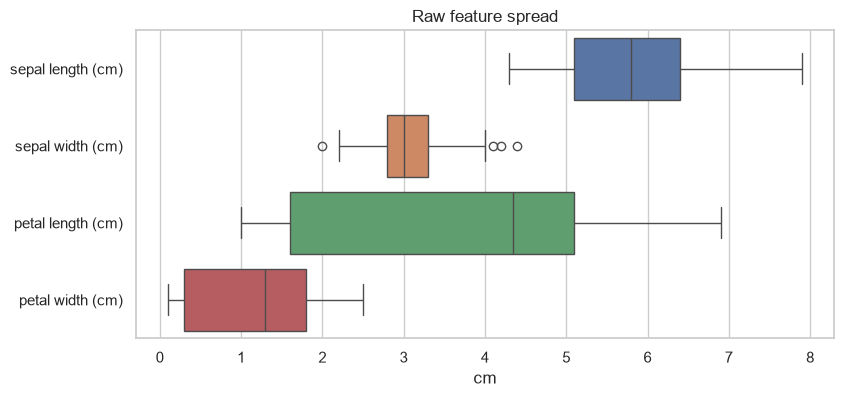

Points outside 1.5*IQR per feature:
 sepal length (cm)    0
sepal width (cm)     4
petal length (cm)    0
petal width (cm)     0
dtype: int64

Skew per feature:
 sepal length (cm)    0.315
sepal width (cm)     0.319
petal length (cm)   -0.275
petal width (cm)    -0.103
dtype: float64


In [5]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df[feature_names], orient="h")
plt.title("Raw feature spread")
plt.xlabel("cm")
plt.show()

q1, q3 = df[feature_names].quantile(0.25), df[feature_names].quantile(0.75)
iqr = q3 - q1
outliers = ((df[feature_names] < q1 - 1.5 * iqr) | (df[feature_names] > q3 + 1.5 * iqr)).sum()
print("Points outside 1.5*IQR per feature:\n", outliers)
print("\nSkew per feature:\n", df[feature_names].skew().round(3))

Only sepal width has outliers by the 1.5x IQR rule, 4 of them out of 150, and every feature has skew below 0.32 in absolute value. That is close enough to symmetric that robust scaling is unnecessary and a z-score is safe.

### Correlation between features

If two features carry nearly the same information, part of the input layer is redundant. Worth checking before deciding whether any reduction step is needed.

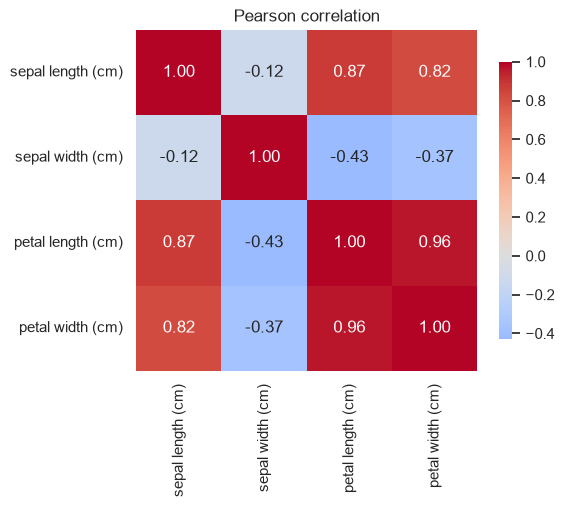

In [6]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(df[feature_names].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Pearson correlation")
plt.show()

Petal length and petal width correlate at 0.96, and both correlate above 0.8 with sepal length. Three of the four features move together almost as one, so the effective dimensionality is lower than 4 and a wide first hidden layer has little extra signal to exploit.

## 3. Missing values

The rule we follow: under 5% missing, drop the rows; 5–15%, impute (mode for categorical, and for numeric look at the distribution — mean if it is symmetric, median if it is skewed); above 15%, drop the column unless it is needed.

In [7]:
missing_pct = df[feature_names].isna().mean() * 100
print("Missing per feature (%):\n", missing_pct.round(2))
print("\nTotal missing cells:", int(df[feature_names].isna().sum().sum()))

Missing per feature (%):
 sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

Total missing cells: 0


There are no missing values, so no branch of the rule applies and no imputation is done. Nothing to plot before and after.

## 4. Split, then scale

Split first and fit the scaler on the training set only, otherwise the test set's mean and variance leak into training. A 70/30 stratified split keeps 35 of each species in train and 15 in test.

Scaling matters more for an MLP than for most models: the first layer computes a weighted sum of the raw inputs, so a feature with a 4x larger spread produces 4x larger gradients for its weights, and Adam then takes badly proportioned steps. Z-score standardisation is the right variant here because the features are continuous and near-symmetric, with only 4 mild outliers that do not justify robust scaling, and because centring at 0 keeps the pre-activations in the part of the ReLU where gradients actually flow.

Train: (105, 4)  Test: (45, 4)
Train class counts: [35 35 35]  Test: [15 15 15]


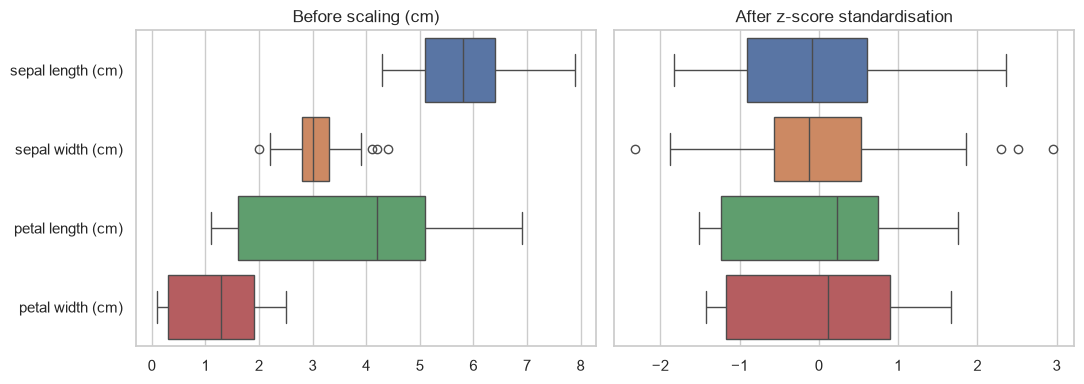

Train means after scaling: [ 0. -0. -0. -0.]
Train stds after scaling:  [1. 1. 1. 1.]


In [8]:
X = df[feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class counts:", np.bincount(y_train), " Test:", np.bincount(y_test))

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=pd.DataFrame(X_train, columns=feature_names), orient="h", ax=axes[0])
axes[0].set_title("Before scaling (cm)")
sns.boxplot(data=pd.DataFrame(X_train_s, columns=feature_names), orient="h", ax=axes[1])
axes[1].set_title("After z-score standardisation")
axes[1].set_yticklabels([])
plt.tight_layout()
plt.show()

print("Train means after scaling:", np.round(X_train_s.mean(axis=0), 3))
print("Train stds after scaling: ", np.round(X_train_s.std(axis=0), 3))

Every feature now sits at mean 0 and standard deviation 1, so no input dominates the first layer's weight updates by scale alone. The sepal width outliers survive, which is what we want, since they are real flowers rather than errors.

## 5. Feature selection and extraction

Since there are only 4 features, we won't be performing selection.

## 6. The two architectures

Both networks use ReLU activations, the Adam solver, `alpha=1e-4` L2 regularisation and the same learning rate, and both sit behind the same `StandardScaler` inside a `Pipeline`. The only thing that changes is the hidden layer specification, so any difference in score is attributable to capacity and depth.

- **Architecture A — `(5,)`**: one hidden layer of 5 neurons. Barely more units than the 4 inputs, so it can only carve out a few boundary pieces.
- **Architecture B — `(32, 16)`**: two hidden layers of 32 and 16 neurons. Roughly 17x the parameters of A and one extra composition step, which lets it bend the boundary in ways A cannot.

In [9]:
ARCH_A, ARCH_B = (5,), (32, 16)

def make_mlp(hidden, seed=RANDOM_STATE):
    """StandardScaler + MLP, so the scaler is refit inside every CV fold."""
    return Pipeline([
        ("scale", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=hidden, activation="relu", solver="adam",
                              alpha=1e-4, learning_rate_init=0.01, max_iter=2000,
                              random_state=seed)),
    ])

def n_params(hidden, n_in=4, n_out=3):
    sizes = [n_in, *hidden, n_out]
    return sum(sizes[i] * sizes[i+1] + sizes[i+1] for i in range(len(sizes) - 1))

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

for name, h in [("A", ARCH_A), ("B", ARCH_B)]:
    print(f"Architecture {name}: hidden={h}  layers={len(h)}  trainable params={n_params(h)}")

Architecture A: hidden=(5,)  layers=1  trainable params=43
Architecture B: hidden=(32, 16)  layers=2  trainable params=739


A has 43 weights and biases, B has 739. Cross-validation is repeated 5-fold run 5 times over, giving 25 fold scores per architecture instead of 5, because with only 105 training rows a single 5-fold estimate moves around too much to compare two models on.

### 6.1 Architecture A — one hidden layer of 5 neurons

Cross-validate first on the training set only. The scaler lives inside the pipeline, so each fold refits it on that fold's training part and the CV estimate stays honest.

In [10]:
res_a = cross_validate(make_mlp(ARCH_A), X_train, y_train, cv=cv,
                       scoring="accuracy", return_train_score=True, n_jobs=-1)
cv_a = res_a["test_score"]
print(f"A {ARCH_A}: CV accuracy {cv_a.mean():.4f} +- {cv_a.std():.4f}"
      f"   (min {cv_a.min():.4f}, max {cv_a.max():.4f})")
print(f"   mean train-fold accuracy {res_a['train_score'].mean():.4f}")

A (5,): CV accuracy 0.9771 +- 0.0384   (min 0.8571, max 1.0000)
   mean train-fold accuracy 0.9962


In [11]:
model_a = make_mlp(ARCH_A).fit(X_train, y_train)
pred_a = model_a.predict(X_test)
acc_a = accuracy_score(y_test, pred_a)

print(f"Epochs to converge: {model_a.named_steps['mlp'].n_iter_}")
print(f"Test accuracy: {acc_a:.4f}\n")
print(classification_report(y_test, pred_a, target_names=iris.target_names))

Epochs to converge: 407
Test accuracy: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



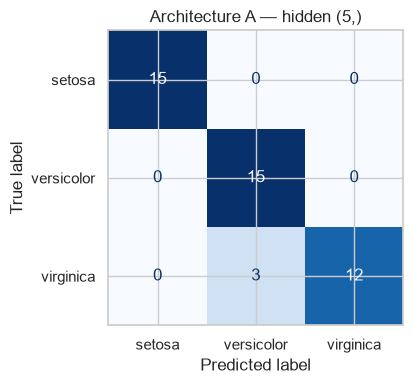

In [12]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_a),
                       display_labels=iris.target_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Architecture A — hidden {ARCH_A}")
plt.tight_layout()
plt.show()

A cross-validates at 0.977 and scores 93.3% on the 45 held-out rows. All 3 errors are the same kind, virginica labelled versicolor, which drops virginica recall to 0.80 while its precision stays at 1.00, and setosa is never missed. The gap between the 0.996 mean training-fold accuracy and the 0.977 validation accuracy is small, so 5 neurons are not memorising the training folds.

### 6.2 Architecture B — two hidden layers of 32 and 16 neurons

17x the parameters. If the extra capacity is useful the validation accuracy should be better; if the problem is too simple for it, the network will fit the training folds perfectly and generalise slightly worse.

In [13]:
res_b = cross_validate(make_mlp(ARCH_B), X_train, y_train, cv=cv,
                       scoring="accuracy", return_train_score=True, n_jobs=-1)
cv_b = res_b["test_score"]
print(f"B {ARCH_B}: CV accuracy {cv_b.mean():.4f} +- {cv_b.std():.4f}"
      f"   (min {cv_b.min():.4f}, max {cv_b.max():.4f})")
print(f"   mean train-fold accuracy {res_b['train_score'].mean():.4f}")

B (32, 16): CV accuracy 0.9543 +- 0.0436   (min 0.8095, max 1.0000)
   mean train-fold accuracy 1.0000


In [14]:
model_b = make_mlp(ARCH_B).fit(X_train, y_train)
pred_b = model_b.predict(X_test)
acc_b = accuracy_score(y_test, pred_b)

print(f"Epochs to converge: {model_b.named_steps['mlp'].n_iter_}")
print(f"Test accuracy: {acc_b:.4f}\n")
print(classification_report(y_test, pred_b, target_names=iris.target_names))

Epochs to converge: 178
Test accuracy: 0.9111

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



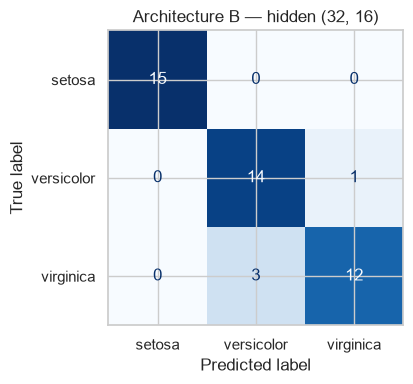

In [15]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_b),
                       display_labels=iris.target_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Architecture B — hidden {ARCH_B}")
plt.tight_layout()
plt.show()

B cross-validates at 0.954, below A, and fits the training folds perfectly at 1.000, and the 4.6-point gap between training and validation is the overfitting signature the extra capacity was expected to produce. On the test set it makes 4 errors instead of 3, adding a versicolor read as virginica to the same 3 virginica-as-versicolor mistakes.

## 7. Comparison

### Cross-validated accuracy across all 25 folds

The mean alone hides how much the two models move from fold to fold, so plot the whole distribution.

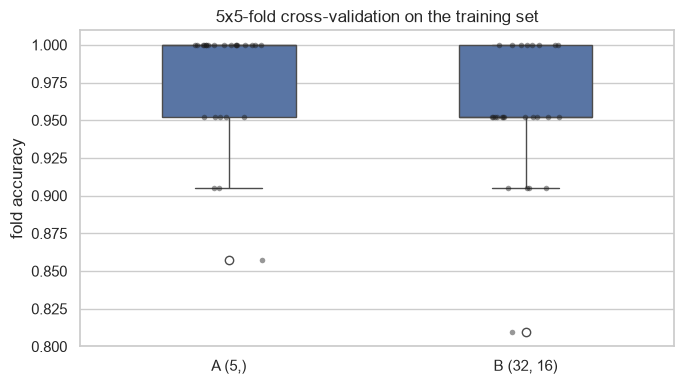

A mean 0.9771  median 1.0000  std 0.0384
B mean 0.9543  median 0.9524  std 0.0436
Folds where A >= B: 25 of 25


In [16]:
fold_df = pd.DataFrame({f"A {ARCH_A}": cv_a, f"B {ARCH_B}": cv_b}).melt(
    var_name="architecture", value_name="fold accuracy")

plt.figure(figsize=(7, 4))
ax = sns.boxplot(data=fold_df, x="architecture", y="fold accuracy", width=0.45)
sns.stripplot(data=fold_df, x="architecture", y="fold accuracy",
              color="k", alpha=0.45, size=4, jitter=0.12, ax=ax)
ax.set_xlabel("")
plt.title("5x5-fold cross-validation on the training set")
plt.tight_layout()
plt.show()

print(f"A mean {cv_a.mean():.4f}  median {np.median(cv_a):.4f}  std {cv_a.std():.4f}")
print(f"B mean {cv_b.mean():.4f}  median {np.median(cv_b):.4f}  std {cv_b.std():.4f}")
print(f"Folds where A >= B: {(cv_a >= cv_b).sum()} of {len(cv_a)}")

A's median fold is a perfect 1.000 against B's 0.952, and A's worst fold is 0.857 against B's 0.810. A scored at least as well as B in all 25 paired folds, so the gap is consistent rather than an average dragged around by a couple of bad folds. Even so, the two distributions overlap heavily and the means are only 2.3 points apart, so this is "A is at least as good", not "A is much better".

### Training loss curves

`loss_curve_` shows how fast each network drove its training loss down, which separates "learns the task quickly" from "generalises well".

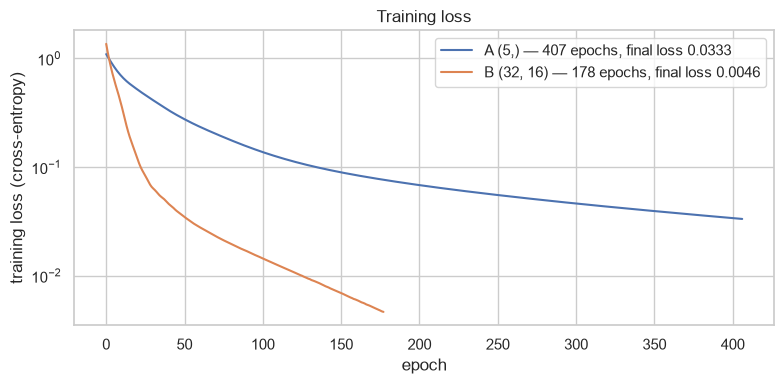

A: epochs to reach loss < 0.2 = 71
B: epochs to reach loss < 0.2 = 15


In [17]:
plt.figure(figsize=(8, 4))
for name, m, h in [("A", model_a, ARCH_A), ("B", model_b, ARCH_B)]:
    net = m.named_steps["mlp"]
    plt.plot(net.loss_curve_, label=f"{name} {h} — {net.n_iter_} epochs, final loss {net.loss_:.4f}")
plt.xlabel("epoch"); plt.ylabel("training loss (cross-entropy)")
plt.yscale("log")
plt.title("Training loss")
plt.legend()
plt.tight_layout()
plt.show()

for name, m in [("A", model_a), ("B", model_b)]:
    lc = m.named_steps["mlp"].loss_curve_
    print(f"{name}: epochs to reach loss < 0.2 = {next(i for i, l in enumerate(lc) if l < 0.2)}")

B drops below 0.2 loss in 15 epochs against A's 71 and finishes at 0.005 versus A's 0.033, so the bigger network learns the training set faster and more completely. That lower training loss buys no test accuracy, which is the point: B is spending its capacity on rows it has already seen.

### Test-set metrics side by side

Macro-averaged precision, recall and F1 alongside accuracy, because accuracy alone would not show that both models fail on one specific class.

In [18]:
def scores(y_true, pred):
    return {"accuracy": accuracy_score(y_true, pred),
            "precision (macro)": precision_score(y_true, pred, average="macro"),
            "recall (macro)": recall_score(y_true, pred, average="macro"),
            "f1 (macro)": f1_score(y_true, pred, average="macro")}

comparison = pd.DataFrame({f"A: hidden {ARCH_A}": scores(y_test, pred_a),
                           f"B: hidden {ARCH_B}": scores(y_test, pred_b)}).T
comparison["CV accuracy (mean)"] = [cv_a.mean(), cv_b.mean()]
comparison["CV accuracy (std)"] = [cv_a.std(), cv_b.std()]
comparison["train-fold accuracy"] = [res_a["train_score"].mean(), res_b["train_score"].mean()]
comparison["params"] = [n_params(ARCH_A), n_params(ARCH_B)]
comparison.round(4)

,accuracy,precision (macro),recall (macro),f1 (macro),CV accuracy (mean),CV accuracy (std),train-fold accuracy,params
"A: hidden (5,)",0.9333,0.9444,0.9333,0.9327,0.9771,0.0384,0.9962,43
"B: hidden (32, 16)",0.9111,0.9155,0.9111,0.9107,0.9543,0.0436,1.0000,739


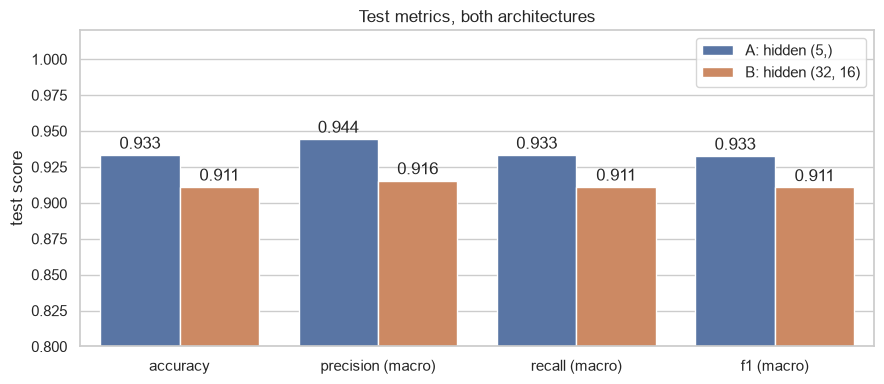

In [19]:
metrics = ["accuracy", "precision (macro)", "recall (macro)", "f1 (macro)"]
plot_df = comparison[metrics].reset_index().melt(id_vars="index", var_name="metric", value_name="score")

plt.figure(figsize=(9, 4))
ax = sns.barplot(data=plot_df, x="metric", y="score", hue="index")
ax.set_ylim(0.8, 1.02)
ax.set_xlabel(""); ax.set_ylabel("test score"); ax.legend(title="")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=2)
plt.title("Test metrics, both architectures")
plt.tight_layout()
plt.show()

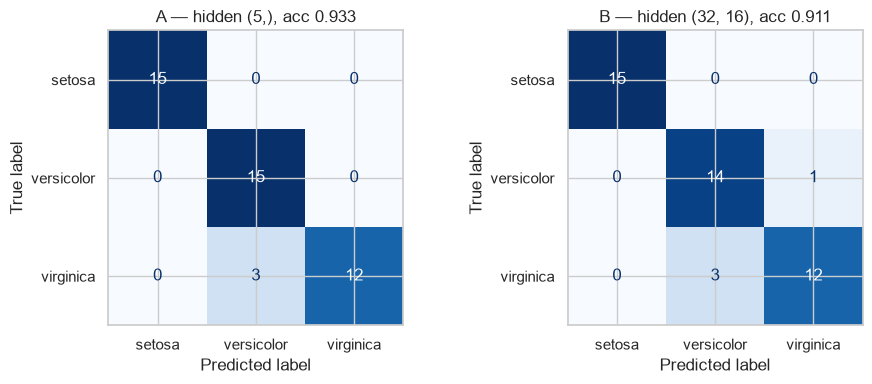

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, (pred, title) in zip(axes, [(pred_a, f"A — hidden {ARCH_A}, acc {acc_a:.3f}"),
                                    (pred_b, f"B — hidden {ARCH_B}, acc {acc_b:.3f}")]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=iris.target_names).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

Setosa is perfect in both confusion matrices and the entire error budget sits on the versicolor/virginica border, exactly where the petal histograms overlapped. Neither model has a precision-versus-recall problem worth trading off: with balanced classes and no asymmetric cost between species, accuracy is the metric that matters here.

### The test set is only 45 rows

One test split is 45 flowers, so a single flower is worth 2.2 points of accuracy. Refitting both architectures under 10 different weight initialisations shows how much of the test gap is real.

In [21]:
seed_rows = []
for name, h in [("A", ARCH_A), ("B", ARCH_B)]:
    accs = [accuracy_score(y_test, make_mlp(h, seed=seed).fit(X_train, y_train).predict(X_test))
            for seed in range(10)]
    seed_rows.append({"architecture": f"{name} {h}", "test acc mean": np.mean(accs),
                      "test acc std": np.std(accs), "min": np.min(accs), "max": np.max(accs)})
seed_df = pd.DataFrame(seed_rows).set_index("architecture")
seed_df.round(4)

,test acc mean,test acc std,min,max
architecture,,,,
"A (5,)",0.9133,0.0156,0.8889,0.9556
"B (32, 16)",0.9289,0.0133,0.9111,0.9556


Averaged over 10 initialisations the test accuracies are 0.913 for A and 0.929 for B, which flips the single-split result. The 1.6-point gap is about the size of each model's own spread across seeds, so 45 rows cannot separate these two architectures and the cross-validated numbers are the ones to trust.

### Computational cost

- B carries 739 weights against A's 43, so every forward and backward pass costs roughly 17 times the arithmetic and 17 times the memory. On 105 flowers that is invisible, but the same ratio on a dataset a thousand times larger is what separates a model that trains in seconds from one that trains in hours.
- B converges in 178 epochs against A's 407, so its total training time is not 17 times worse. Training is paid once while the per-prediction cost is paid on every flower the model ever sees, which keeps A the cheaper one to deploy.

## 8. Inferences

- Iris is clean: 150 rows, 4 numeric features, no missing cells and 50 rows per species, so no imputation branch ran and plain accuracy is a fair headline metric.
- Z-score standardisation was the right scaler, because the features are near-symmetric with only 4 mild sepal width outliers, and an MLP's first layer would otherwise take badly proportioned gradient steps on the widest-ranging feature.
- Splitting before scaling and keeping the scaler inside the `Pipeline` stops test statistics from leaking into training or into the cross-validation estimate.
- With only 4 features and no redundancy worth removing, nothing was selected or extracted; the petal histograms already showed that petal length and width carry most of the class signal.
- Architecture A `(5,)` cross-validated at 0.977 ± 0.038 and architecture B `(32, 16)` at 0.954 ± 0.044, so the smaller network is slightly ahead despite having 43 parameters against B's 739.
- B fits the training folds perfectly at 1.000 while A stops at 0.996, and B's validation accuracy is the lower of the two, so the extra capacity bought memorisation rather than generalisation.
- On the single 45-row test split A scored 93.3% and B 91.1%, but over 10 weight initialisations that order reverses to 0.913 against 0.929, so the test-set gap is noise and the CV comparison is the one to quote.
- Every error in both models is on the versicolor/virginica border and setosa is never missed, which is exactly what the petal histograms predicted.
- B reached a training loss of 0.005 in 178 epochs against A's 0.033 in 407, so the deeper network learns faster per epoch while ending up no better on unseen flowers.
- B does about 17x the arithmetic per pass for the same accuracy, and it pays that cost on every prediction, not only during training.
- The practical conclusion is to prefer A: same accuracy within noise, a seventeenth of the parameters, and less to go wrong when the training set is only 105 rows.